In [1]:
pip install rdkit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install dgllife

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Loading file to Pandas DF + Add SMILES for primary and secondary ligand + solvent one hot encoder + Molecules structures

In [3]:
from rdkit.Chem import AllChem
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import pandas as pd
import numpy as np
import seaborn as sn
#---------------------- RDKit packages
from rdkit.Chem import rdMolDescriptors
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
#------------------- progress bar
from tqdm import tqdm
#------------------- hide warning
import warnings
from urllib.request import urlopen
from urllib.parse import quote
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import Image, display
from IPython.display import display, HTML
import base64
from PIL import Image as PILImage
from io import BytesIO
from sklearn.preprocessing import OneHotEncoder
warnings.filterwarnings('ignore')


dataset=pd.read_excel("../../data/SF_DATA_EMISSION_PEAK.xlsx", sheet_name='EQE_CLEANED')
#dataset=dataset_full.iloc[:5]

master_smiles_map = {
    'ethanamine': 'CCN',
    'propan-1-amine': 'CCCN',
    'propan-2-amine': 'CC(N)C',
    'butan-1-amine': 'CCCCN',
    'pentan-1-amine': 'CCCCCN',
    'propane-1,3-diamine': 'NCCCN',
    'pentane-1,5-diamine': 'NCCCCCN',
    'N-(2-bromoethyl)propane-1,3-diamine': 'BrCCNCCCN',
    '2-phenylethan-1-amine': 'NCCc1ccccc1',
    '1-phenylethan-1-amine': 'CC(N)c1ccccc1',
    '3,3-diphenylpropan-1-amine': 'NCCC(c1ccccc1)c2ccccc2',
    '4-phenylbutan-1-amine': 'NCCCCc1ccccc1',
    '4-phenylbutan-2-amine': 'CC(N)CCc1ccccc1',
    'benzene-1,4-dimethanamine': 'NCc1ccc(CN)cc1',
    "[1,1':3',1'':3'',1'''-quaterphenyl]-4-ylmethanamine": 
        'NCc1ccc(cc1)-c2cccc(c2)-c3cccc(c3)-c4ccccc4',
    '1-(naphthalen-1-yl)ethan-1-amine': 'CC(N)c1cccc2ccccc12',
    'naphthalen-1-ylmethanamine': 'NCc1cccc2ccccc12',
    '2-(2-fluorophenyl)ethan-1-amine': 'NCCc1c(F)cccc1',
    '2-(3-fluorophenyl)ethan-1-amine': 'NCCc1cc(F)ccc1',
    '2-(4-fluorophenyl)ethan-1-amine': 'NCCc1ccc(F)cc1',
    '2-(2-methoxyphenyl)ethan-1-amine': 'NCCc1c(OC)cccc1',
    '2-(3-methoxyphenyl)ethan-1-amine': 'COc1cc(CCN)ccc1',
    '2-(4-methoxyphenyl)ethan-1-amine': 'COc1ccc(CCN)cc1',
    '2-phenoxyethan-1-amine': 'NCCOc1ccccc1',
    '2-(thiophen-2-yl)ethan-1-amine': 'NCCc1cccs1',
    "2-[5-(2,2'-dimethyl-[1,1'-biphenyl]-4-yl)thiophen-2-yl]ethan-1-amine":
        'Cc1ccccc1-c2c(C)cc(cc2)-c3ccc(CCN)s3',
    "2-[5-(3',5'-dimethyl-[1,1'-biphenyl]-4-yl)thiophen-2-yl]ethan-1-amine":
        'Cc1cc(C)cc(c1)-c2ccc(cc2)-c3ccc(CCN)s3',
    '2-[2-(2-aminoethoxy)ethoxy]ethan-1-amine': 'NCCOCCOCCN',
    'adamantan-1-amine': 'NC12CC3CC(C1)CC(C3)C2',
    'ethanimidamide': 'CC(=N)N',
    'guanidine': 'NC(=N)N'
}

#-----------------------
def CIRconvert(ids):
    if pd.isna(ids):
        return None
    try:
        url = 'http://cactus.nci.nih.gov/chemical/structure/' + quote(ids) + '/smiles'
        ans = urlopen(url).read().decode('utf8')
        return ans
    except:
        if ids in master_smiles_map:
            return master_smiles_map[ids]
        return 'Could not find SMILES'
        
dataset["PRIMARY_ORGANIC_SPACER_SMILES"]=dataset["PRIMARY_ORGANIC_SPACER_IUPAC"].apply(CIRconvert)
dataset["SECONDARY_ORGANIC_SPACER_SMILES"]=dataset["SECONDARY_ORGANIC_SPACER_IUPAC"].apply(CIRconvert)

#-------------------------
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
solvent_df = dataset[['SOLVENT']]
encoded_array = encoder.fit_transform(solvent_df)
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(['SOLVENT']))
dataset = pd.concat([dataset.drop('SOLVENT', axis=1), encoded_df], axis=1)

#----------------------------
def smile_to_mol(smiles):
    if not smiles:
        return None
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol
    except:
        return None
    
dataset["PRIMARY_ORGANIC_SPACER_MOL"]=dataset["PRIMARY_ORGANIC_SPACER_SMILES"].apply(smile_to_mol)
dataset["SECONDARY_ORGANIC_SPACER_MOL"]=dataset["SECONDARY_ORGANIC_SPACER_SMILES"].apply(smile_to_mol)

#----------------------------
def render_mol(mol):
    if not mol:
        return None
    img = Draw.MolToImage(mol)
    img_buffer = BytesIO()
    img.save(img_buffer, format="PNG")
    img_str = base64.b64encode(img_buffer.getvalue()).decode("utf-8")
    return f'<img src="data:image/png;base64,{img_str}" width="150">'

dataset["PRIMARY_ORGANIC_SPACER_STRUCT"]=dataset["PRIMARY_ORGANIC_SPACER_MOL"].apply(render_mol)
dataset["SECONDARY_ORGANIC_SPACER_STRUCT"]=dataset["SECONDARY_ORGANIC_SPACER_MOL"].apply(render_mol)

#---------------------------
#display(dataset)
#dataset.drop(columns='Mol', axis=1, inplace=True)
#dataset.drop(columns='Struct', axis=1, inplace=True)

#display(HTML(dataset.to_html(escape=False)))
with open('results_table.html', 'w', encoding='utf-8') as f:
    f.write(dataset.to_html(escape=False))
#-----------------

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
dataset.head()

,REFERENCE_DOI,IS_MIXED_SPACERS_SPACER,PRIMARY_ORGANIC_SPACER_IUPAC,CL_PRIMARY_ORGANIC_HALIDE,BR_PRIMARY_ORGANIC_HALIDE,I_PRIMARY_ORGANIC_HALIDE,PRIMARY_SPACER_FRACTION,SECONDARY_ORGANIC_SPACER_IUPAC,CL_SECONDARY_ORGANIC_HALIDE,BR_SECONDARY_ORGANIC_HALIDE,I_SECONDARY_ORGANIC_HALIDE,SECONDARY_SPACER_FRACTION,SPACER_TO_PB_RATIO,PbCl2,PbBr2,PbI2,CsCl_TO_Pb,CsBr_TO_Pb,CsI_TO_Pb,RbBr_TO_Pb,RbI_TO_Pb,FABr_TO_Pb,FAI_TO_Pb,MABr_TO_Pb,MAI_TO_Pb,EMISSION_PEAK_NM,PHOTON_ENERGY_EV,Additive,Processing_Temp_C,Annealing_Time_min,HTL,ETL,EQE_percent,PRIMARY_ORGANIC_SPACER_SMILES,SECONDARY_ORGANIC_SPACER_SMILES,SOLVENT_DMF,SOLVENT_DMF:DMSO,SOLVENT_DMSO,SOLVENT_NMP,PRIMARY_ORGANIC_SPACER_MOL,SECONDARY_ORGANIC_SPACER_MOL,PRIMARY_ORGANIC_SPACER_STRUCT,SECONDARY_ORGANIC_SPACER_STRUCT
0,10.1002/aelm.202201199,0,2-phenylethan-1-amine,0,1,0,1.0,NaN,0,0,0,0.0,0.67,0.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,0.66,0.0,0.0,0.0,530.0,2.34,NaN,80.0,60.0,PEDOT:PSS/PSS-Na,TPBI/LiF,12.71,NCCc1ccccc1,None,0.0,0.0,1.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x00000298C5F...,None,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",None
1,10.1002/aelm.202201199,0,2-phenylethan-1-amine,0,1,0,1.0,NaN,0,0,0,0.0,0.67,0.0,1.0,0.0,0.0,0.0,0.0,0.33,0.0,0.66,0.0,0.0,0.0,530.0,2.34,RbBr,80.0,60.0,PEDOT:PSS/PSS-Na,TPBI/LiF,18.92,NCCc1ccccc1,None,0.0,0.0,1.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x00000298C5F...,None,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",None
2,10.1002/adom.202302664,0,2-phenylethan-1-amine,0,1,0,1.0,NaN,0,0,0,0.0,0.40,0.0,1.0,0.0,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,512.0,2.42,NaN,80.0,5.0,PVK,TPBI/LiF,4.26,NCCc1ccccc1,None,0.0,0.0,1.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x00000298C5F...,None,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",None
3,10.1002/adom.202302664,0,2-phenylethan-1-amine,0,1,0,1.0,NaN,0,0,0,0.0,0.40,0.0,1.0,0.0,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,512.0,2.42,TPBi - 1,80.0,5.0,PVK,TPBI/LiF,5.08,NCCc1ccccc1,None,0.0,0.0,1.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x00000298C5F...,None,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",None
4,10.1002/adom.202302664,0,2-phenylethan-1-amine,0,1,0,1.0,NaN,0,0,0,0.0,0.40,0.0,1.0,0.0,0.0,1.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,512.0,2.42,TPBi - 2,80.0,5.0,PVK,TPBI/LiF,7.05,NCCc1ccccc1,None,0.0,0.0,1.0,0.0,<rdkit.Chem.rdchem.Mol object at 0x00000298C5F...,None,"<img src=""data:image/png;base64,iVBORw0KGgoAAA...",None


In [4]:
print(dataset.shape)
dataset.replace("NaN", np.nan, inplace=True)
dataset.replace("N/A", np.nan, inplace=True)

dataset['Additive'] = dataset['Additive'].fillna('None').astype(str)
dataset['HTL'] = dataset['HTL'].fillna('Unknown_HTL').astype(str)
dataset['ETL'] = dataset['ETL'].fillna('Unknown_ETL').astype(str)
dataset['Processing_Temp_C'] = pd.to_numeric(dataset['Processing_Temp_C'])
dataset['Processing_Temp_C'] = dataset['Processing_Temp_C'].fillna(dataset['Processing_Temp_C'].median())

dataset['Annealing_Time_min'] = pd.to_numeric(dataset['Annealing_Time_min'])
dataset['Annealing_Time_min'] = dataset['Annealing_Time_min'].fillna(dataset['Annealing_Time_min'].median())
print(dataset.tail())

(258, 43)
          REFERENCE_DOI  IS_MIXED_SPACERS_SPACER PRIMARY_ORGANIC_SPACER_IUPAC  \
253  10.1039/d0tc05227b                        0        2-phenylethan-1-amine   
254  10.1039/d0tc05227b                        0        2-phenylethan-1-amine   
255  10.1039/d0tc05227b                        0        2-phenylethan-1-amine   
256  10.1039/d0tc05227b                        0        2-phenylethan-1-amine   
257  10.1039/d0tc05227b                        0        2-phenylethan-1-amine   

     CL_PRIMARY_ORGANIC_HALIDE  BR_PRIMARY_ORGANIC_HALIDE  \
253                          0                          1   
254                          0                          1   
255                          0                          1   
256                          0                          1   
257                          0                          1   

     I_PRIMARY_ORGANIC_HALIDE  PRIMARY_SPACER_FRACTION  \
253                         0                      1.0   
254                 

2D Molecular discriptors - All existing features + 200 Molecular discriptors

In [5]:
calc = MoleculeDescriptors.MolecularDescriptorCalculator([x[0] for x in Descriptors._descList])
desc_names = calc.GetDescriptorNames()

def get_2d_descriptors_safe(smiles):
    if pd.isna(smiles) or str(smiles).strip() == "":
        return [None] * len(desc_names)
    
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return [None] * len(desc_names)
        
        # Calculate descriptors (Notice we do NOT AddHs here!)
        return calc.CalcDescriptors(mol)
    except Exception:
        return [None] * len(desc_names)

primary_smiles = dataset['PRIMARY_ORGANIC_SPACER_SMILES'].dropna().unique().tolist()
secondary_smiles = dataset['SECONDARY_ORGANIC_SPACER_SMILES'].dropna().unique().tolist()
unique_smiles = list(set(primary_smiles + secondary_smiles))
print(f"Found {len(unique_smiles)} unique molecules. Calculating {len(desc_names)} descriptors...")


features_dict = {}
for sm in unique_smiles:
    features_dict[sm] = get_2d_descriptors_safe(sm)

df_unique_features = pd.DataFrame.from_dict(features_dict, orient='index', columns=desc_names)
df_primary_features = df_unique_features.add_prefix('Pri_')
df_secondary_features = df_unique_features.add_prefix('Sec_')

dataset = dataset.merge(
    df_primary_features, 
    how='left', 
    left_on='PRIMARY_ORGANIC_SPACER_SMILES', 
    right_index=True
)

dataset = dataset.merge(
    df_secondary_features, 
    how='left', 
    left_on='SECONDARY_ORGANIC_SPACER_SMILES', 
    right_index=True
)

print("\n--- Featurization Complete! ---")

columns_to_omit = ['REFERENCE_DOI', 'PRIMARY_ORGANIC_SPACER_IUPAC', 'SECONDARY_ORGANIC_SPACER_IUPAC', 'PRIMARY_ORGANIC_SPACER_SMILES', 'SECONDARY_ORGANIC_SPACER_SMILES', 'PRIMARY_ORGANIC_SPACER_MOL', 'SECONDARY_ORGANIC_SPACER_MOL', 'PRIMARY_ORGANIC_SPACER_STRUCT', 'SECONDARY_ORGANIC_SPACER_STRUCT']
dataset_final = dataset.drop(columns=columns_to_omit)
#dataset_final = dataset_final.fillna(0)
dataset_final.head()
print(dataset_final.shape)

Found 29 unique molecules. Calculating 217 descriptors...

--- Featurization Complete! ---
(258, 468)


Data split to training and testing - Stratified splitting + Choosing Y

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import sklearn
sklearn.set_config(enable_metadata_routing=True)

X = dataset_final.drop(columns=['EQE_percent'])
y = dataset_final['EQE_percent']


stratify_col = (X['IS_MIXED_SPACERS_SPACER'] > 0).astype(int) 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=stratify_col
)

Feature elimination by 1) Corelation matrices and 2) RFECV  (Recusive Feature Elimination using Cross Validation)

In [8]:
from sklearn.feature_selection import RFE
from sklearn.feature_selection import VarianceThreshold

# 1. AGGRESSIVE PRUNING: Variance Threshold
# Drops features where 95% of the values are exactly the same
variance_filter = VarianceThreshold(threshold=0.05)
X_train_var = pd.DataFrame(
    variance_filter.fit_transform(X_train), 
    columns=X_train.columns[variance_filter.get_support()],
    index=X_train.index
)
X_test_var = X_test[X_train_var.columns]

# 2. STRICTER CORRELATION LIMIT: 0.80 instead of 0.90
corr_matrix = X_train_var.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]
print(f"Dropping {len(to_drop)} highly correlated features.")

X_train_uncorr = X_train_var.drop(columns=to_drop)
X_test_uncorr = X_test_var.drop(columns=to_drop)

print(f"Features remaining before RFE: {X_train_uncorr.shape[1]}")

# 3. Temporarily encode string categories into numbers just for the RandomForest
X_train_encoded = X_train_uncorr.copy()
X_test_encoded = X_test_uncorr.copy()

string_cols = X_train_encoded.select_dtypes(include=['object', 'string']).columns.tolist()
if string_cols:
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_encoded[string_cols] = encoder.fit_transform(X_train_encoded[string_cols].astype(str))
    X_test_encoded[string_cols] = encoder.transform(X_test_encoded[string_cols].astype(str))


# 4. HARD CAP FEATURE SELECTION: RFE (Not RFECV)
weights = compute_sample_weight(class_weight='balanced', y=stratify_col.loc[X_train.index])

selector_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=5,              # Very shallow trees to prevent noise learning
    min_samples_leaf=5,       
    random_state=42
)

print("\nStarting RFE to narrow down to exactly 20 features...")
rfe = RFE(
    estimator=selector_model,
    n_features_to_select=20,  # <-- THIS IS THE MAGIC NUMBER FOR 260 ROWS
    step=2                    # Drops 2 features at a time to speed it up
)

# Fit RFE using the ENCODED dataset
rfe.fit(X_train_encoded, y_train)

# Get the final 20 features
selected_feature_indices = rfe.support_
best_features = X_train_uncorr.columns[selected_feature_indices]

print(f"Final selected features (Strictly 20):\n{best_features.tolist()}")

# Create final datasets by slicing the original UNENCODED data (keeps strings intact!)
X_train_final = X_train_uncorr[best_features]
X_test_final = X_test_uncorr[best_features]

print(f"\nFinal Training Data Shape: {X_train_final.shape}")
print(f"Final Testing Data Shape: {X_test_final.shape}")

Dropping 169 highly correlated numerical features.
Total features remaining before RFE: 57

Starting RFE to narrow down to exactly 20 features...
Final selected features (Strictly 20):
['BR_PRIMARY_ORGANIC_HALIDE', 'SPACER_TO_PB_RATIO', 'PbBr2', 'CsBr_TO_Pb', 'FABr_TO_Pb', 'MABr_TO_Pb', 'Processing_Temp_C', 'Annealing_Time_min', 'Pri_MolWt', 'Pri_Ipc', 'Pri_Kappa2', 'Pri_SMR_VSA5', 'Pri_EState_VSA5', 'Pri_EState_VSA7', 'Sec_MolWt', 'Sec_BalabanJ', 'Sec_EState_VSA4', 'Additive', 'HTL', 'ETL']

Final Training Data Shape: (206, 20)
Final Testing Data Shape: (52, 20)


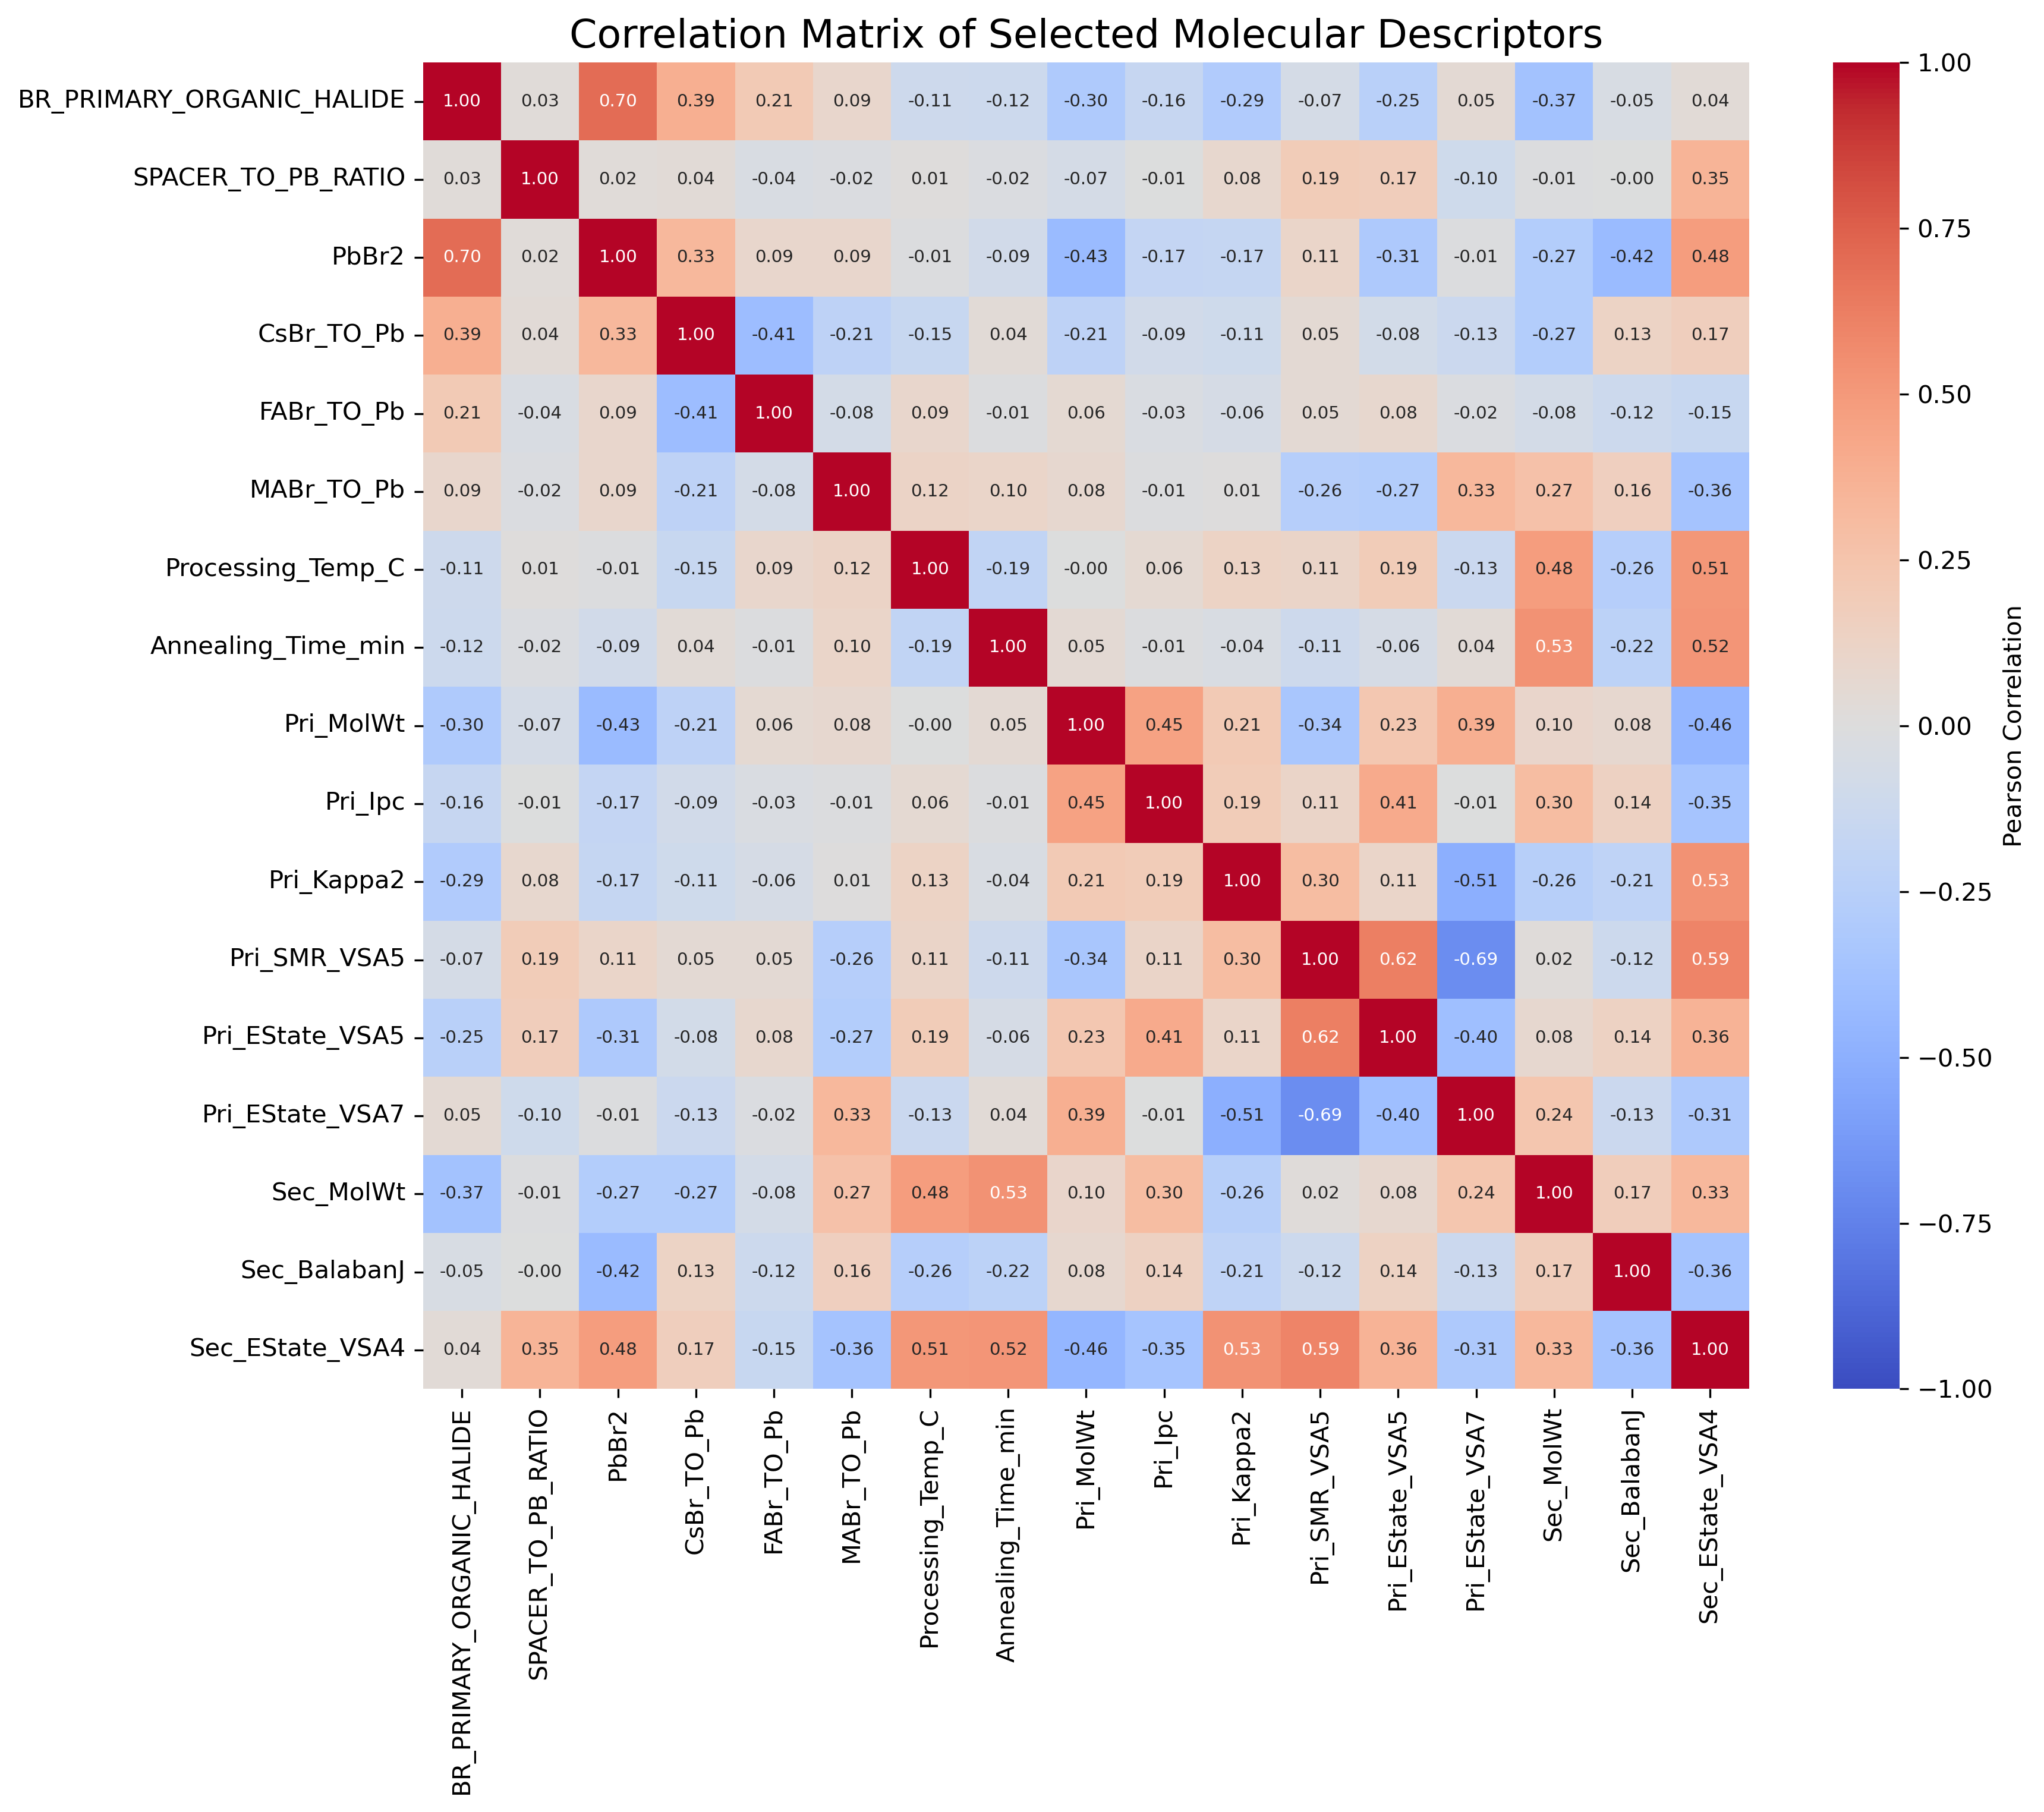

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10), dpi=300) 

# ERROR FIX: Add numeric_only=True to ignore the 'HTL', 'ETL', and 'Additive' strings
final_corr = X_train_final.corr(numeric_only=True)

# heatmap
sns.heatmap(final_corr, 
            annot=True,          
            fmt=".2f",           
            cmap='coolwarm',     
            vmin=-1, vmax=1, 
            square=True, 
            annot_kws={"size": 7}, # Shrunk the numbers so they don't overlap
            cbar_kws={'label': 'Pearson Correlation'})

plt.title("Correlation Matrix of Selected Molecular Descriptors", fontsize=16)

# Ensure labels fit nicely
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()

# Saved with 'EQE' in the name since we are forecasting EQE now
plt.savefig("Figure_2_Correlation_Heatmap_Clean_EQE.png") 
plt.show()

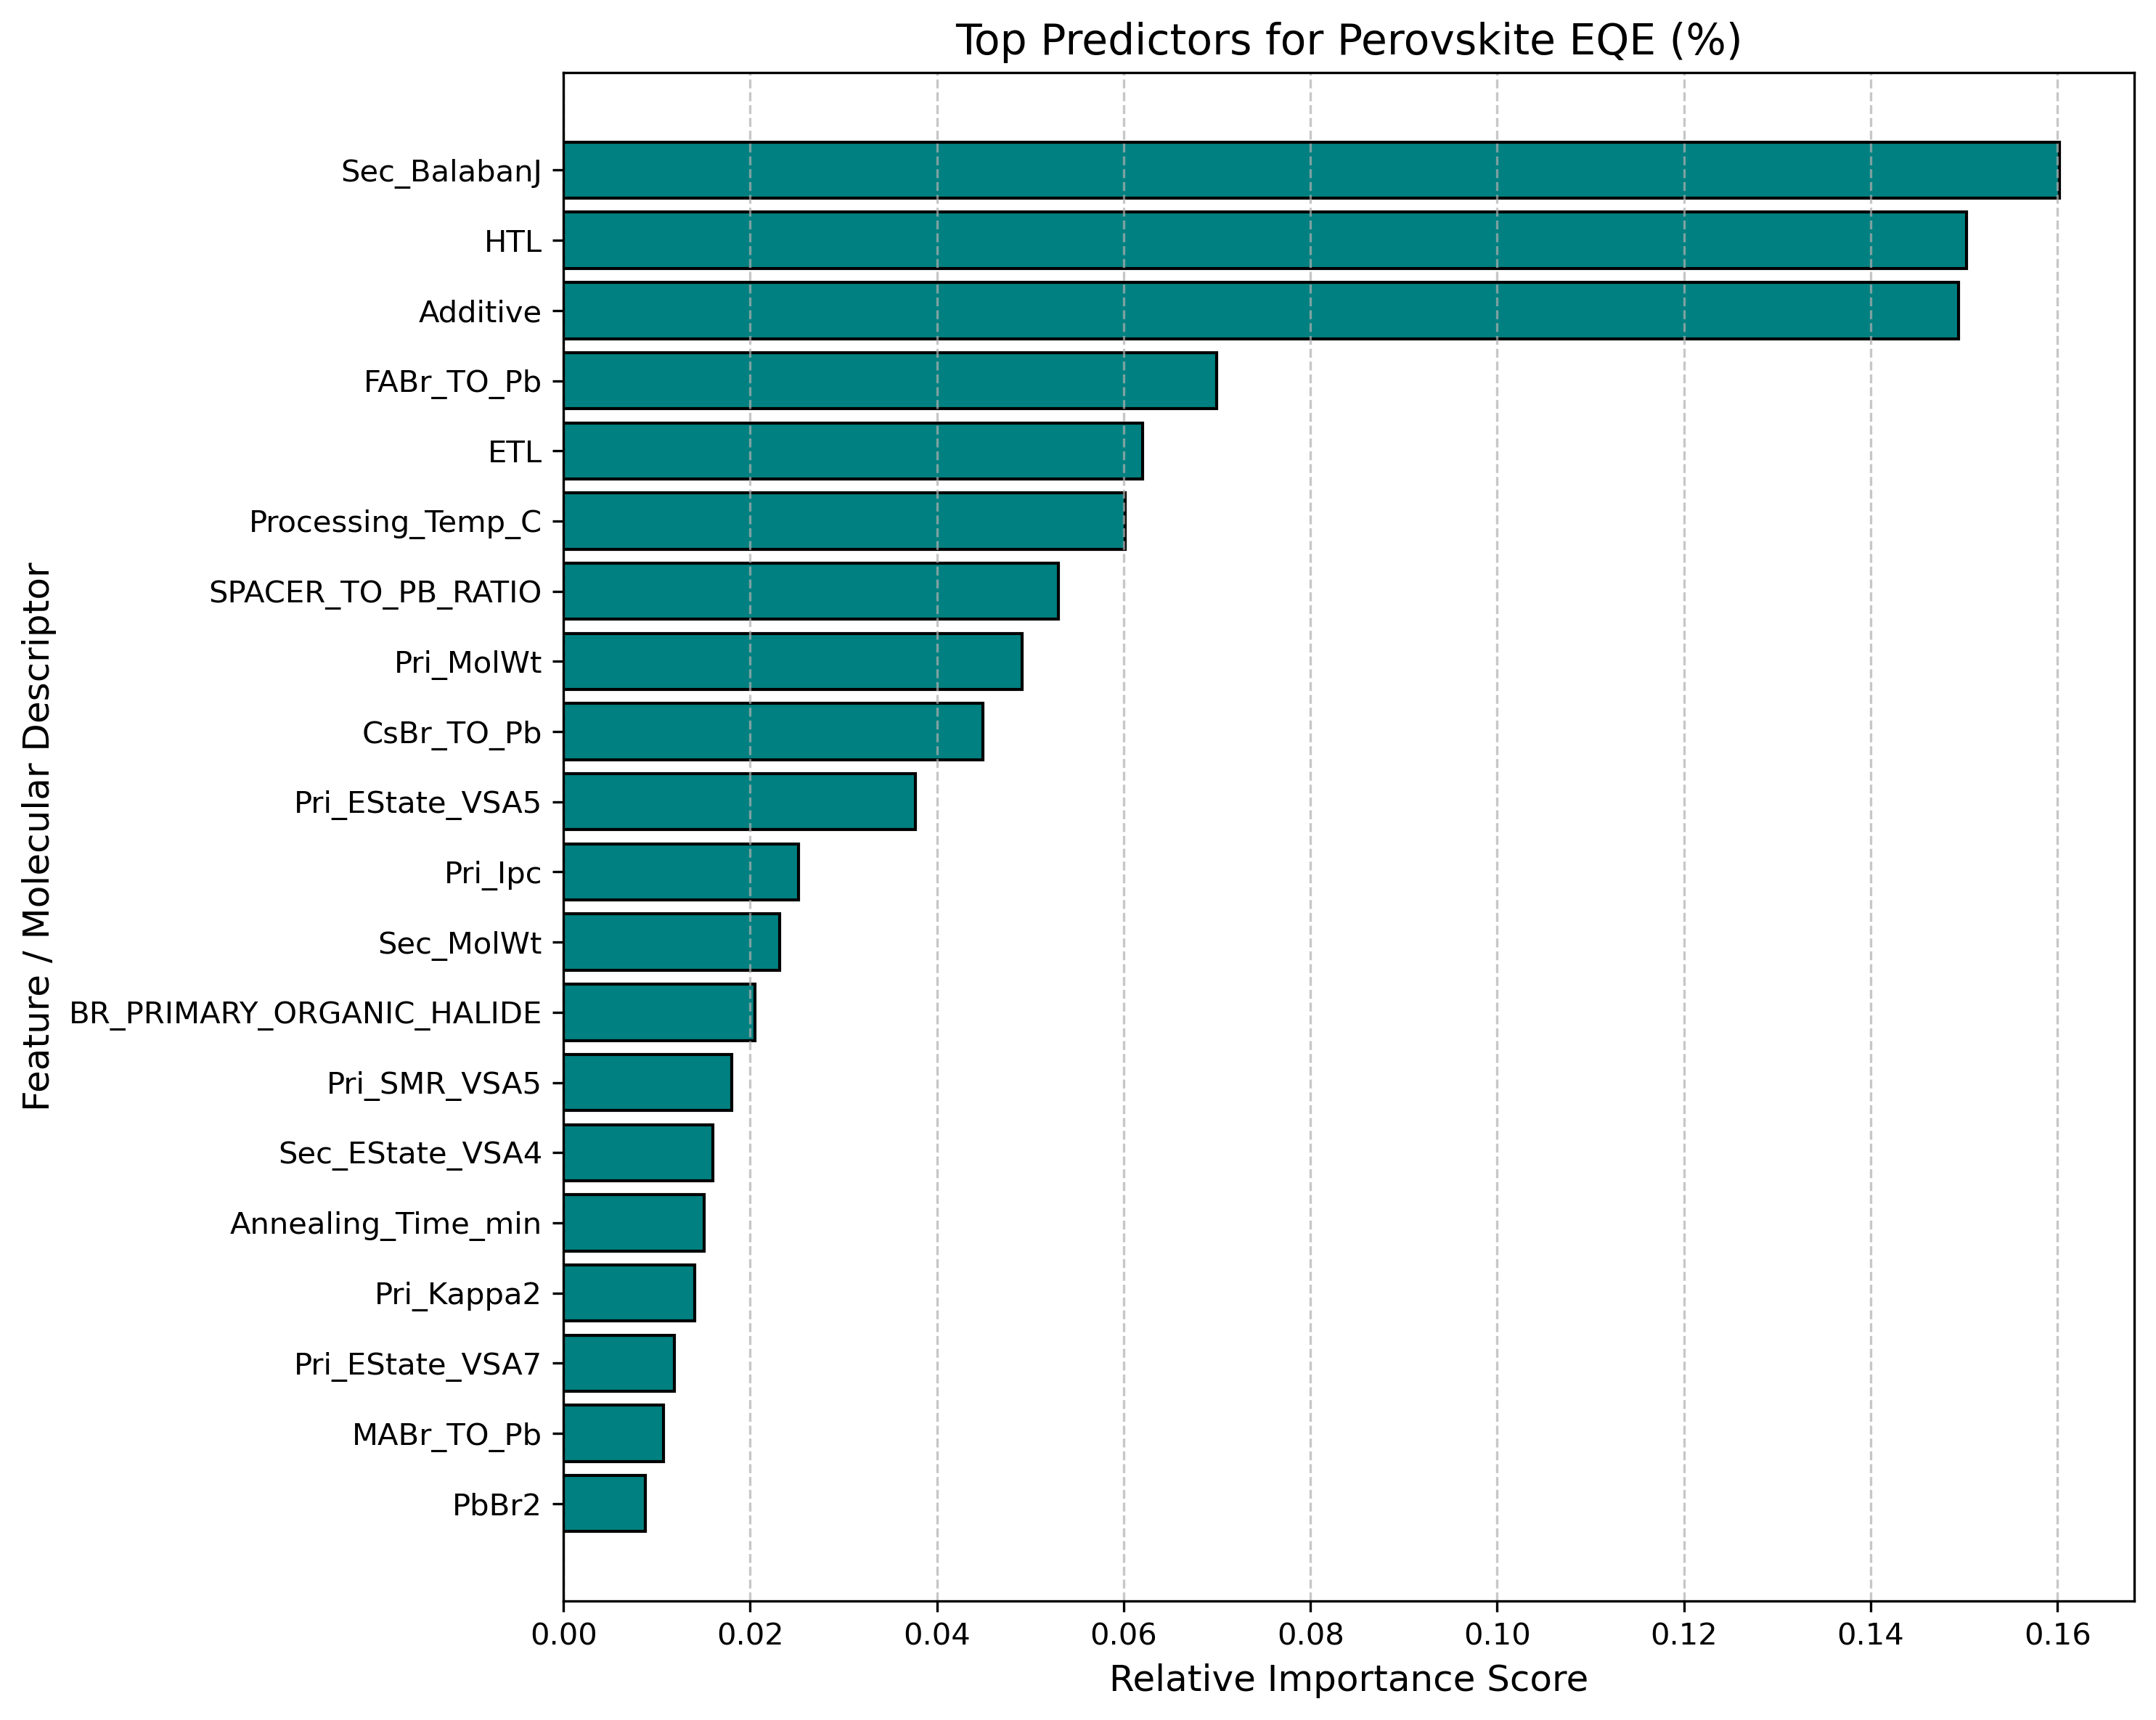

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ERROR FIX: Extract importances from the fitted estimator INSIDE the RFE object
importances = rfe.estimator_.feature_importances_
feature_names = X_train_final.columns

# Sort them from highest to lowest
sorted_indices = np.argsort(importances)
sorted_importances = importances[sorted_indices]
sorted_features = feature_names[sorted_indices]

# Create the Bar Chart
plt.figure(figsize=(10, 8), dpi=300) # Increased height slightly so 20 labels fit perfectly
plt.barh(sorted_features, sorted_importances, color='teal', edgecolor='black')

plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Feature / Molecular Descriptor", fontsize=12)
plt.title("Top Predictors for Perovskite EQE (%)", fontsize=14) # Updated title
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Figure_3_Feature_Importance_EQE.png") # Updated file name
plt.show()

In [11]:
!pip install xgboost
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


Preparing Data and Starting Hyperparameter Tuning...

Tuning XGBoost...
Tuning CatBoost...

bestTest = 5.658887864
bestIteration = 499


bestTest = 5.364713803
bestIteration = 299


bestTest = 5.362257993
bestIteration = 790


bestTest = 5.028039712
bestIteration = 799


bestTest = 4.965461565
bestIteration = 150


bestTest = 4.85763271
bestIteration = 264


bestTest = 5.528359808
bestIteration = 798


bestTest = 5.100656651
bestIteration = 284


bestTest = 5.041561102
bestIteration = 637


bestTest = 5.238283103
bestIteration = 799


bestTest = 4.904516491
bestIteration = 258


bestTest = 5.048552439
bestIteration = 316


bestTest = 5.146203603
bestIteration = 82


bestTest = 5.449477276
bestIteration = 299


bestTest = 4.948351889
bestIteration = 754


bestTest = 5.053262077
bestIteration = 498


bestTest = 5.280666209
bestIteration = 493


bestTest = 5.034173569
bestIteration = 345


bestTest = 5.456504878
bestIteration = 799


bestTest = 5.089138823
bestIteration = 783

Training on

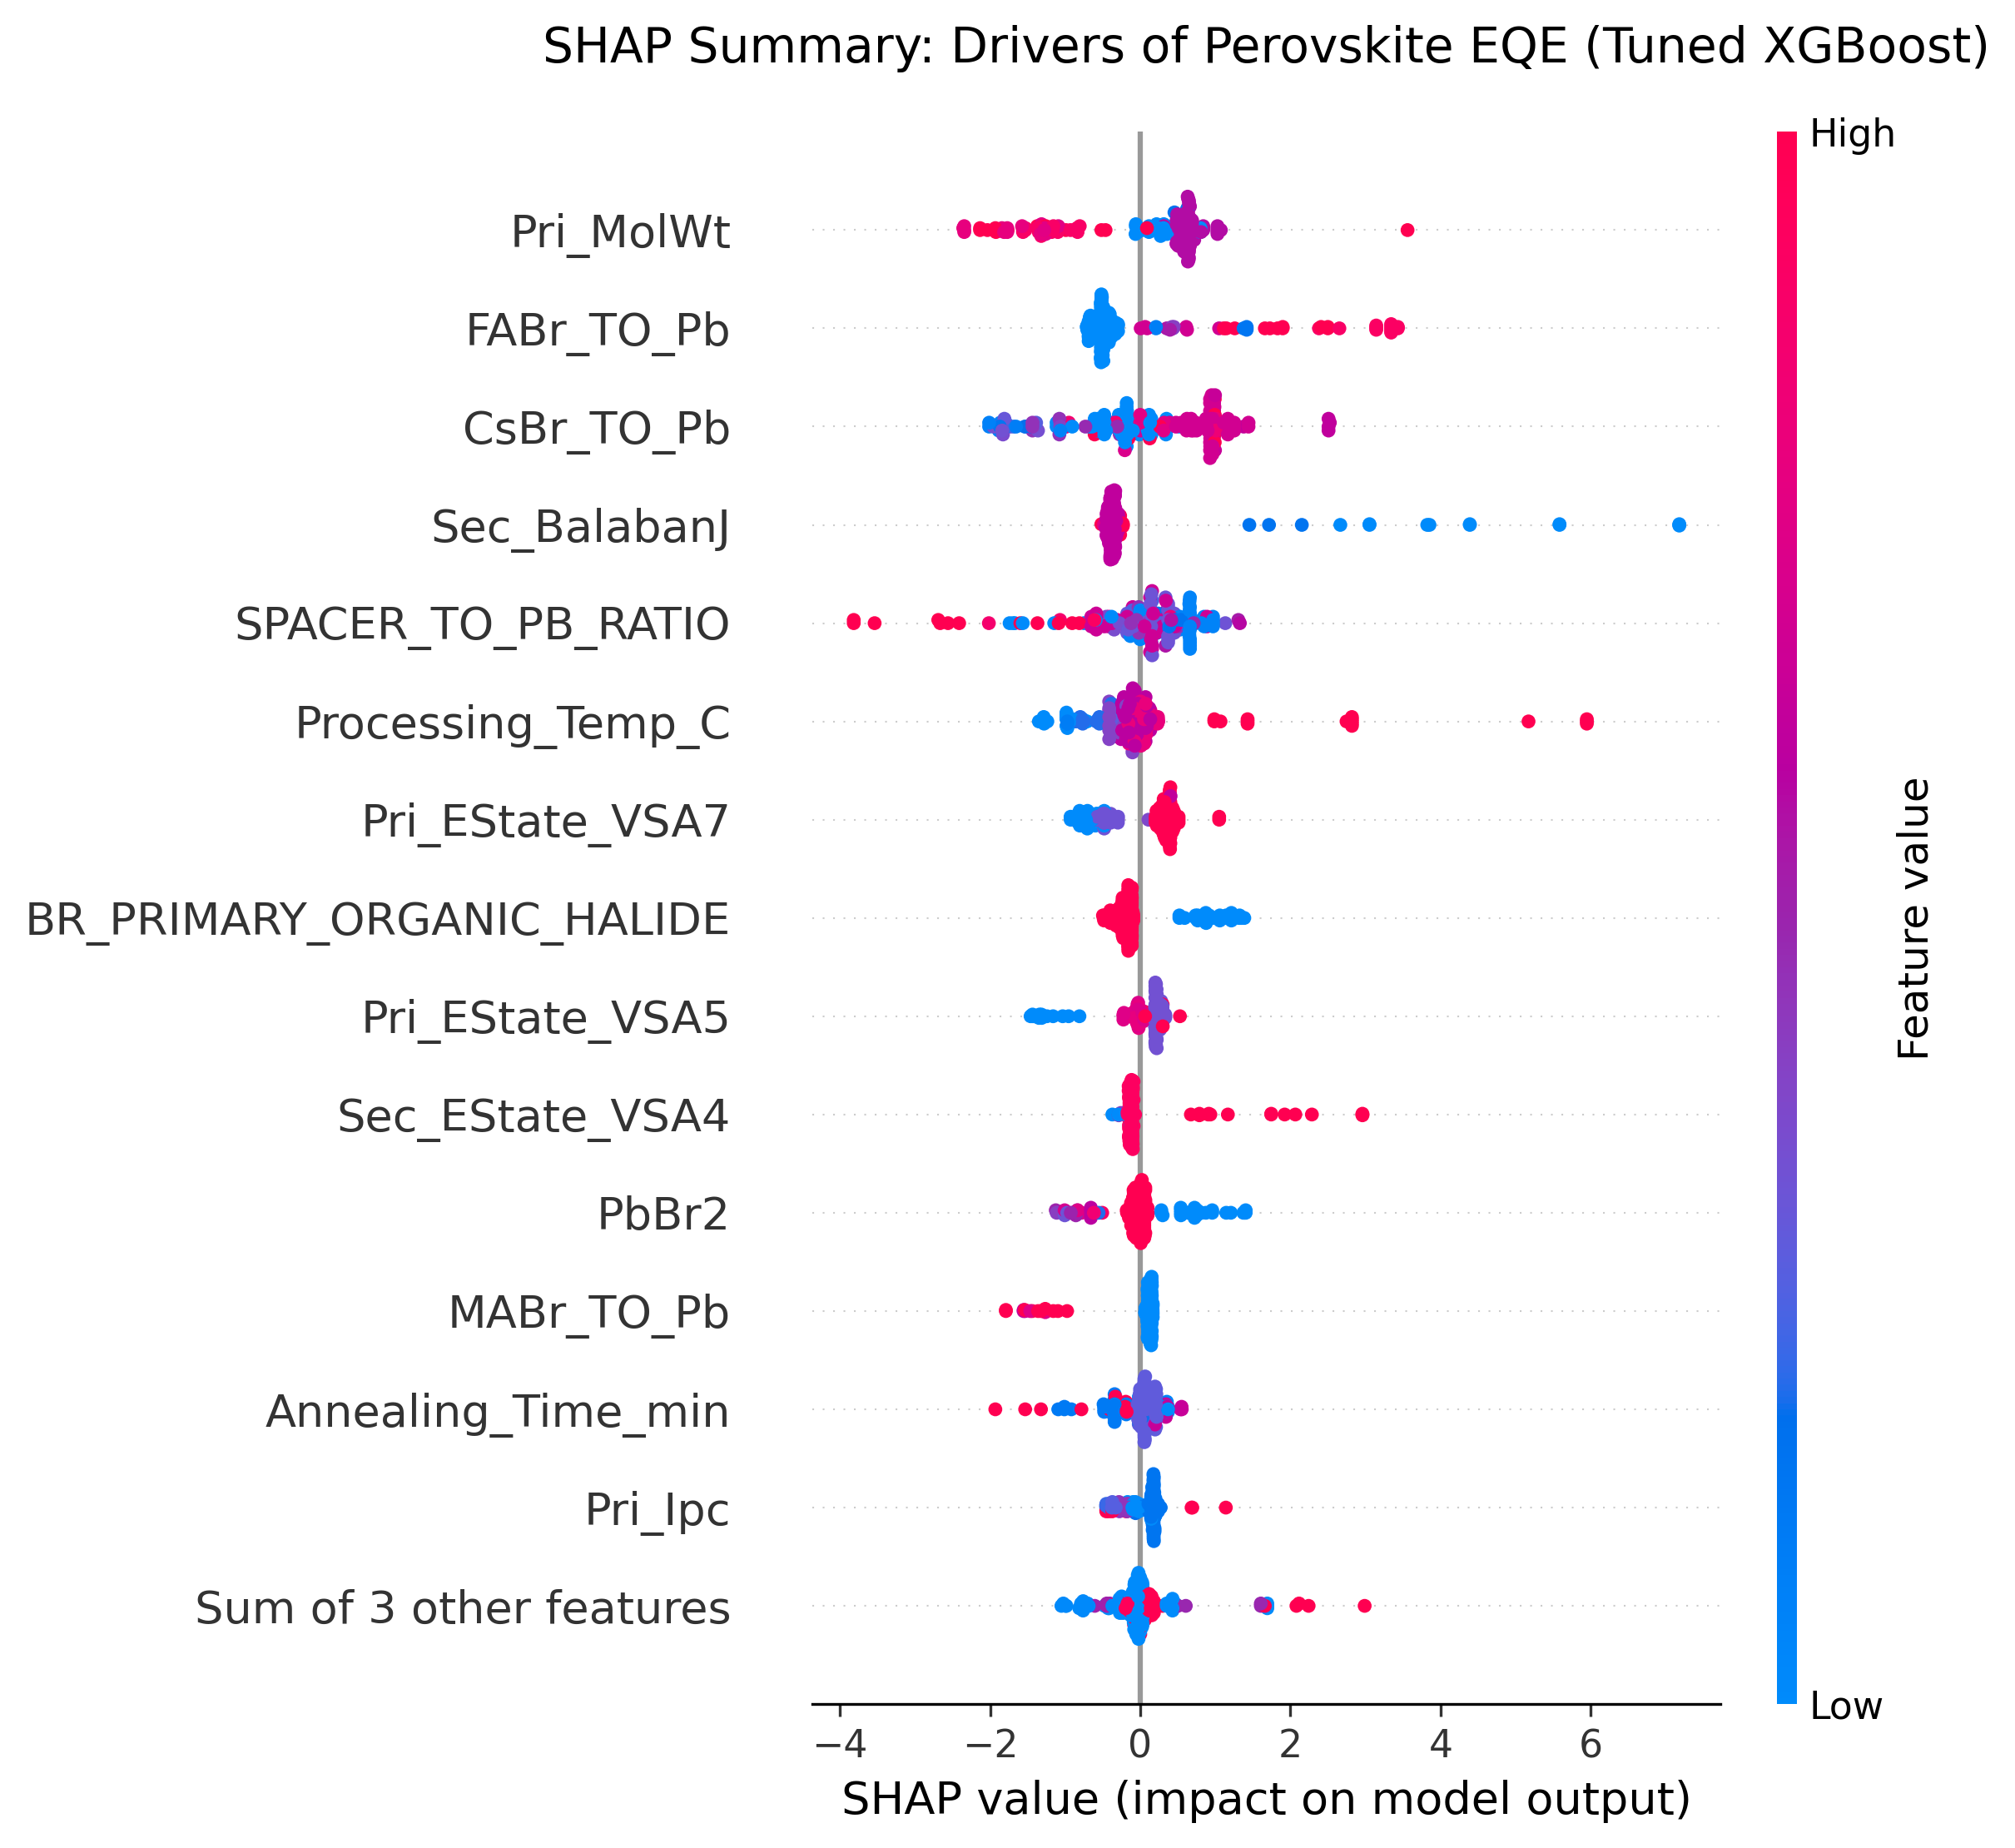

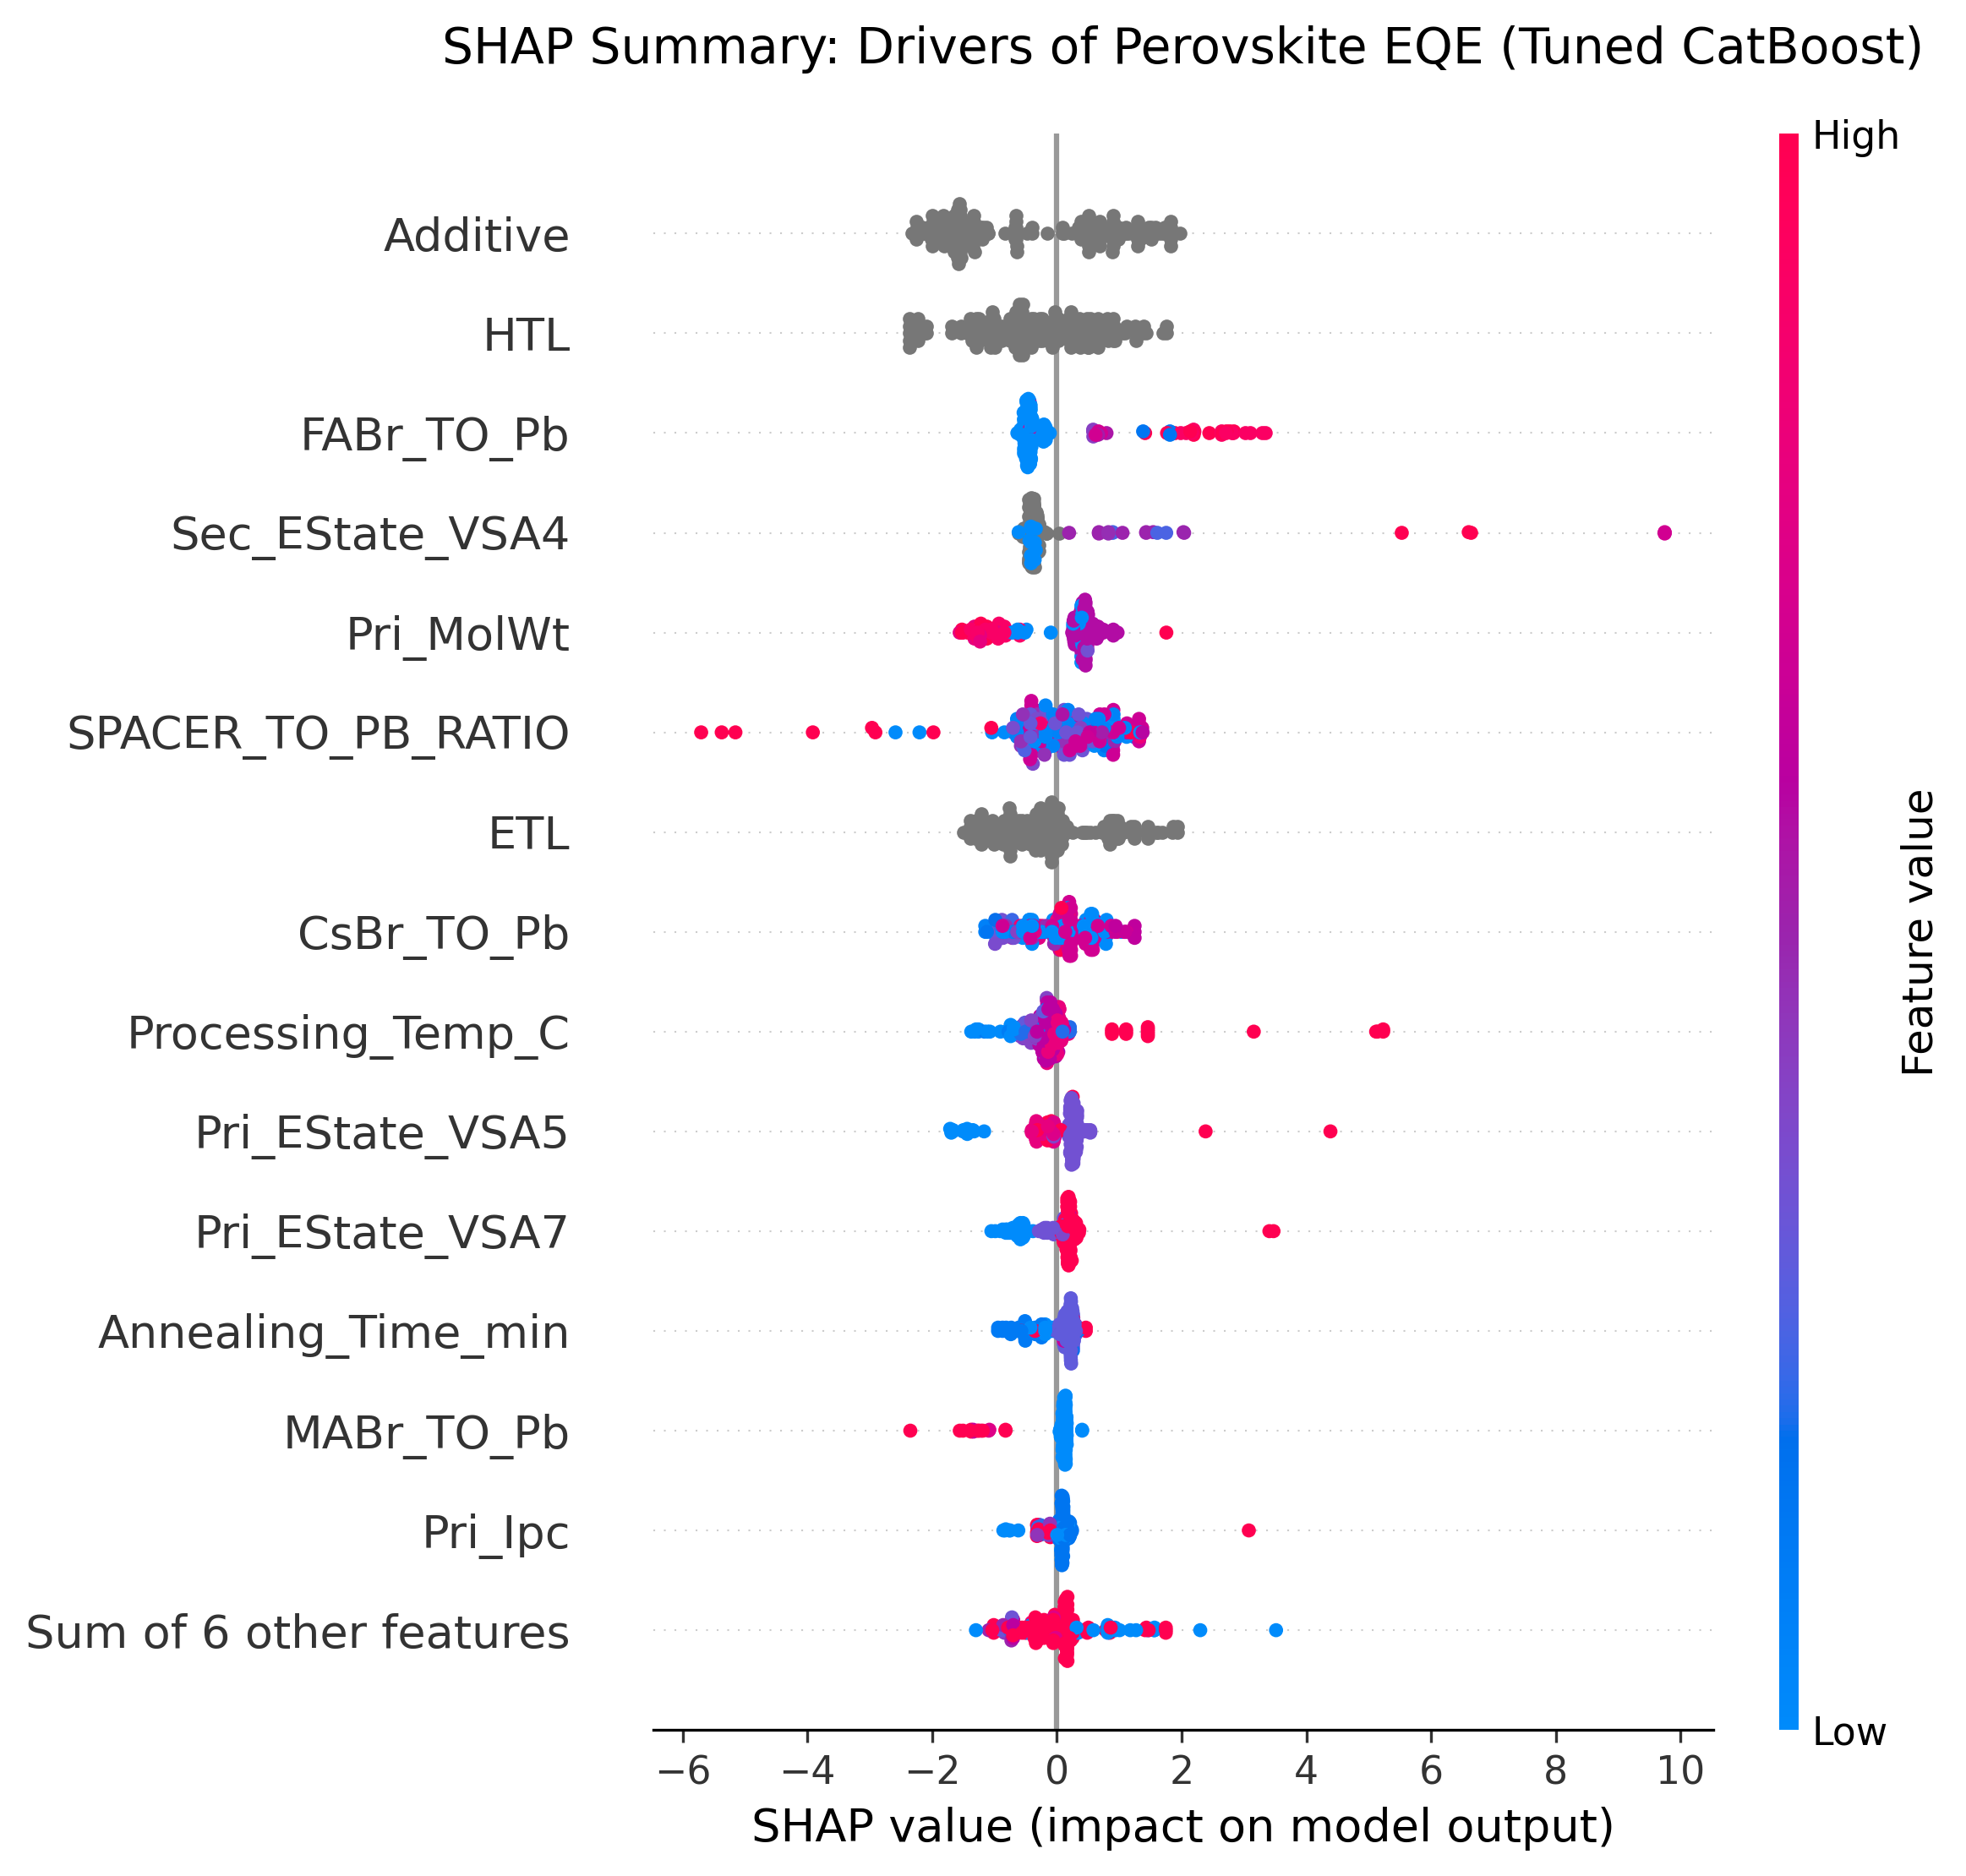

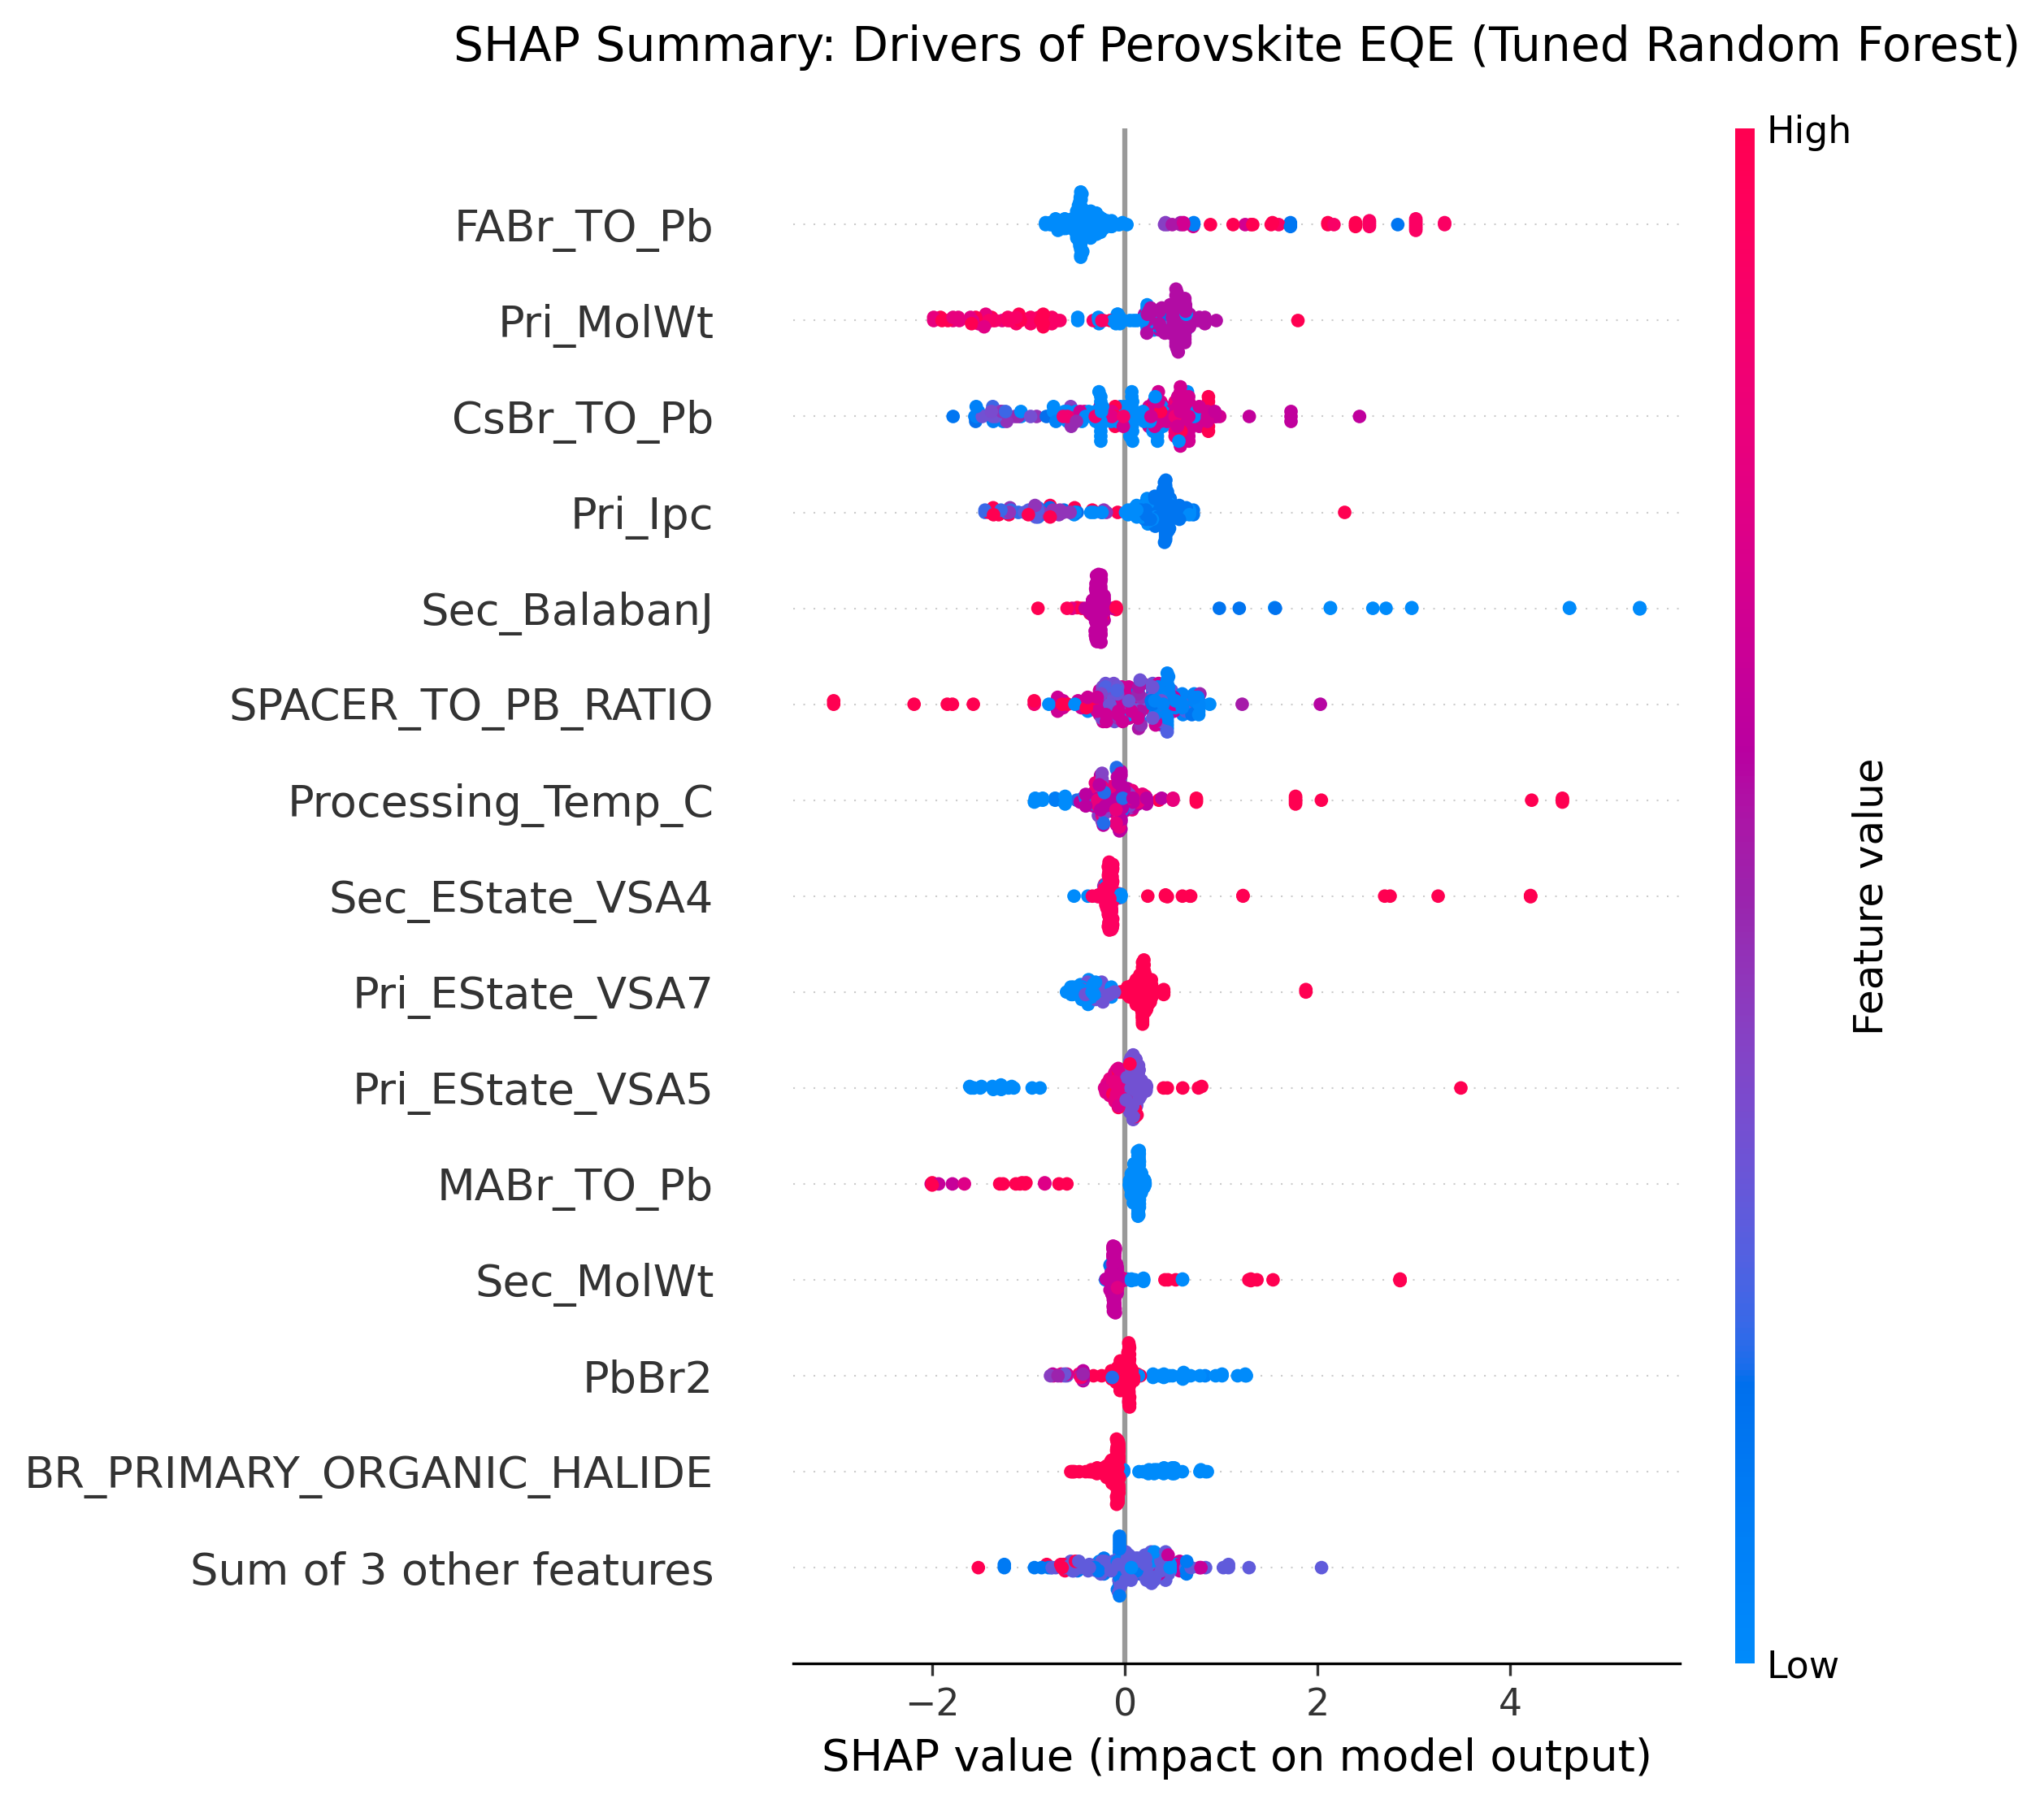

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

print("Preparing Data and Starting Hyperparameter Tuning...\n")

# ==========================================
# 0. PREPARE DATA (NO SCALER NEEDED FOR TREES)
# ==========================================
string_cols = X_train_final.select_dtypes(include=['object', 'string']).columns.tolist()
cat_features = [col for col in X_train_final.columns if col in string_cols]
num_features = [col for col in X_train_final.columns if col not in string_cols]

# A. Data for CatBoost (Strings kept intact)
X_train_cat = X_train_final.copy()
X_test_cat = X_test_final.copy()
for col in cat_features:
    X_train_cat[col] = X_train_cat[col].fillna('Unknown').astype(str)
    X_test_cat[col] = X_test_cat[col].fillna('Unknown').astype(str)

# B. Data for XGBoost & RF (Drop strings, Fill missing numbers, NO SCALING)
# We still need the imputer to prevent NaN crashes in XGBoost/RF
imputer = SimpleImputer(strategy='median')
X_train_num_processed = pd.DataFrame(imputer.fit_transform(X_train_final[num_features]), columns=num_features)
X_test_num_processed = pd.DataFrame(imputer.transform(X_test_final[num_features]), columns=num_features)


# ==========================================
# 1. TUNE XGBOOST
# ==========================================
print("Tuning XGBoost...")
xgb_param_grid = {
    'n_estimators': [100, 300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 2, 4]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=30,                     
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,                     
    random_state=42
)
xgb_search.fit(X_train_num_processed, y_train)
best_xgb = xgb_search.best_estimator_


# ==========================================
# 2. TUNE CATBOOST
# ==========================================
print("Tuning CatBoost...")
cat_param_grid = {
    'iterations': [300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 5, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 9],
    'random_strength': [0.1, 1, 5]
}

best_cat = CatBoostRegressor(cat_features=cat_features, verbose=0, random_seed=42)
cat_search_results = best_cat.randomized_search(
    cat_param_grid,
    X=X_train_cat,
    y=y_train,
    cv=5,
    n_iter=20,
    verbose=False,
    plot=False
)


# ==========================================
# 3. TUNE RANDOM FOREST
# ==========================================
print("Tuning Random Forest...")
rf_param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    random_state=42
)
rf_search.fit(X_train_num_processed, y_train)
best_rf = rf_search.best_estimator_


# ==========================================
# 4. EVALUATE THE TUNED MODELS
# ==========================================
print("\nEvaluating Tuned Models on Test Set...")

models = {
    "Tuned XGBoost": best_xgb,
    "Tuned CatBoost": best_cat,
    "Tuned Random Forest": best_rf
}

results = []

for name, model in models.items():
    if "CatBoost" in name:
        y_pred = model.predict(X_test_cat)
    else:
        y_pred = model.predict(X_test_num_processed)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "RMSE (EQE %)": rmse,
        "MAE (EQE %)": mae
    })

benchmark_df = pd.DataFrame(results).sort_values(by="RMSE (EQE %)", ascending=True).reset_index(drop=True)
print("\n--- FINAL TUNED EQE FORECASTING RESULTS ---")
print(benchmark_df.to_string(index=False))


# ==========================================
# 5. GENERATE SHAP PLOTS FOR TUNED MODELS
# ==========================================
print("\nGenerating SHAP Summary Plots in Real Physical Units...")

for name, model in models.items():
    plt.figure(figsize=(10, 8), dpi=300)
    
    if "CatBoost" in name:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_train_cat)
        shap.plots.beeswarm(shap_values, max_display=15, show=False)
        
    elif name in ["Tuned Random Forest", "Tuned XGBoost"]:
        explainer = shap.TreeExplainer(model)
        # We pass the unscaled data here so the x-axis shows physical numbers!
        shap_values = explainer(X_train_num_processed)
        shap.plots.beeswarm(shap_values, max_display=15, show=False)

    plt.title(f"SHAP Summary: Drivers of Perovskite EQE ({name})", fontsize=14, pad=20)
    plt.tight_layout()
    
    safe_name = name.replace(' ', '_')
    plt.savefig(f"Figure_SHAP_{safe_name}_EQE.png", bbox_inches='tight')
    plt.show()